# Airline Passenger Satisfaction Prediction

## Introduction

Customer satisfaction is one of the most important indicators in the airline industry, as it directly affects customer loyalty and business performance. Understanding which factors influence passenger satisfaction can help airlines improve their services and optimize the overall travel experience.

This project uses an airline passenger experience dataset containing demographic information, flight characteristics, service quality ratings, and delay-related variables. and aims to build a machine learning model capable of predicting whether a passenger is satisfied or dissatisfied.

The objectives of this project are:

Perform an Exploratory Data Analysis (EDA) to understand the dataset and identify relevant patterns.
Investigate the relationship between passenger satisfaction and the available features.
Apply statistical feature selection techniques to identify the most informative variables.
Compare different classification algorithms, including Logistic Regression, Random Forest, and AdaBoost.
Optimize the best-performing models through hyperparameter tuning.
Evaluate the final models using multiple performance metrics.

The results show that ensemble-based methods achieve the highest predictive performance, with Random Forest providing the best overall balance between accuracy and robustness. These findings suggest that passenger satisfaction depends on complex and non-linear relationships between customer characteristics, flight conditions, and service quality indicators.

In [46]:
"""
Import the libraries required for data analysis, visualization, and machine learning tasks.

These libraries provide tools for:
- Data manipulation and processing (pandas, numpy)
- Data visualization (matplotlib, seaborn)
- Statistical analysis and feature selection
- Baseline model implementation (DummyClassifier)
- Machine learning models (Logistic Regression, Random Forest, AdaBoost)
- Model performance evaluation
"""

# -----------------------
# Standard library
# -----------------------
import time
import random

# -----------------------
# Third-party
# -----------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# -----------------------
# Feature selection
# -----------------------
from sklearn.feature_selection import chi2, mutual_info_classif

# -----------------------
# Preprocessing
# -----------------------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# -----------------------
# Models
# -----------------------
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# -----------------------
# Model selection
# -----------------------
from sklearn.model_selection import cross_val_score, GridSearchCV

# -----------------------
# Metrics
# -----------------------
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

## Reproducibility Setup

In [49]:
"""
Reproducibility setup.

This block sets global random seeds for NumPy and Python's random module
to ensure full reproducibility of all experiments in the pipeline.
"""
SEED = 48

np.random.seed(48)
random.seed(48)

## Data Loading and Initial Exploration

The dataset was temporarily concatenated for exploratory data analysis purposes only. This operation may introduce data leakage at the exploratory stage; however, it does not affect the modeling pipeline, where train-test separation is strictly preserved.

In [52]:
"""
The training and test datasets are loaded and concatenated to facilitate a comprehensive exploratory data analysis (EDA).
"""

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

df = pd.concat([train, test], axis=0, ignore_index=True)

print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(129880, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location             

The unified dataset allows for an overall analysis of the data distribution without separating training and test sets.
The data shows missing values in the "Arrival Delay in Minutes" feature, which require appropriate handling.

## Data cleaning and handling of missing values

In [56]:
"""
The dataset was cleaned by removing non-informative identifier columns such as
"id" and "Unnamed: 0", as they do not contribute to the predictive task.

Missing values in the "Arrival Delay in Minutes" feature were analyzed before
imputation. The proportion of missing observations was calculated and the
missing values were then filled using the median arrival delay within groups
sharing the same departure delay. Any remaining missing values were replaced
with the overall median of the feature.
"""

df = df.drop(columns=["id", "Unnamed: 0"])

missing_count = df["Arrival Delay in Minutes"].isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

print(f"Missing values: {missing_count}")
print(f"Percentage of missing values: {missing_percentage:.2f}%")

df["Arrival Delay in Minutes"] = (
    df.groupby("Departure Delay in Minutes")["Arrival Delay in Minutes"]
    .transform(lambda x: x.fillna(x.median()))
)

df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
    df["Arrival Delay in Minutes"].median()
)

remaining_missing = df["Arrival Delay in Minutes"].isnull().sum()

print(f"Remaining missing values: {remaining_missing}")

Missing values: 393
Percentage of missing values: 0.30%
Remaining missing values: 0


The feature "Arrival Delay in Minutes" contained 393 missing values (0.30% of the dataset).

A two-step median imputation strategy was applied:
1. Median imputation within groups sharing the same departure delay.
2. Global median imputation for any remaining missing values.

After preprocessing, no missing values remained in the dataset.

## Exploratory Data Analysis(EDA)

### Numerical Feature Distributions

C:\Users\MineT\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\MineT\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\MineT\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\MineT\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

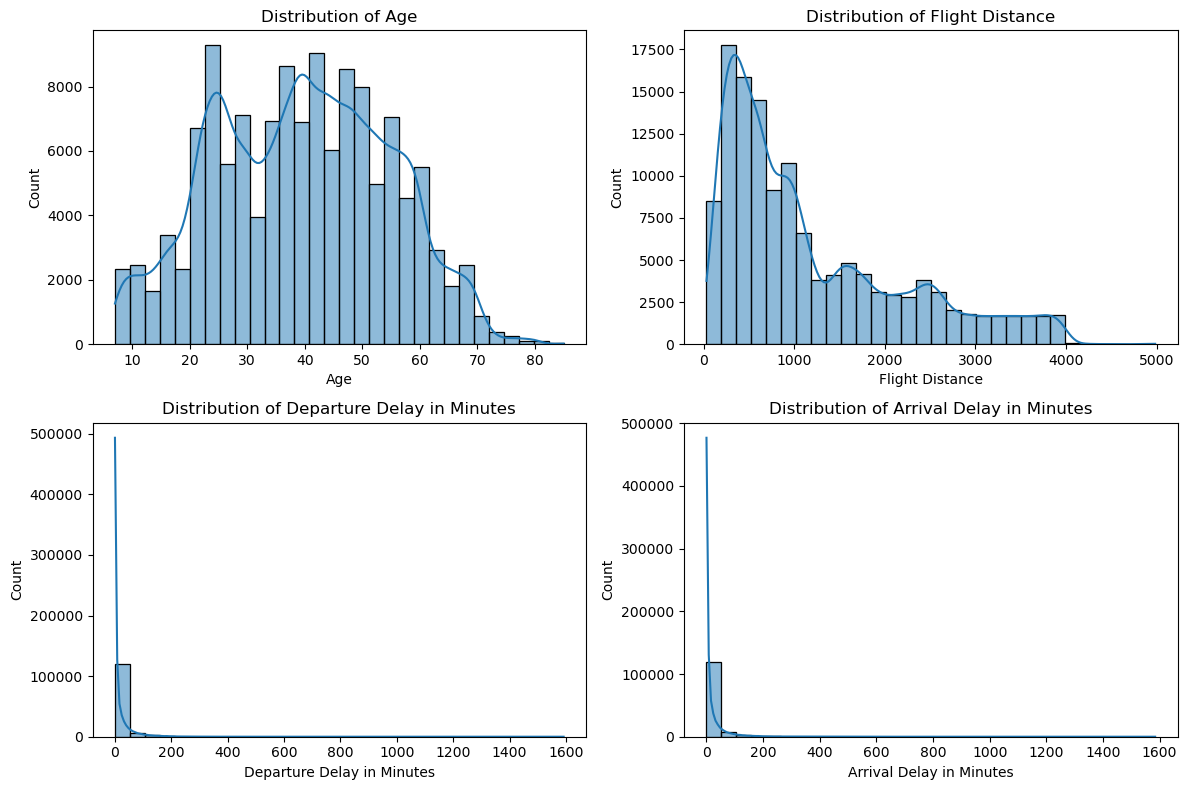

In [61]:
"""
Visualize the distributions of the numerical variables to assess their shape,
identify potential skewness, and detect the presence of extreme values.
"""

numeric_cols = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

The numerical variables exhibit different distribution patterns.

Age and Flight Distance show relatively broad distributions, while Departure Delay and Arrival Delay are strongly right-skewed. This indicates that most flights experience limited delays, whereas a smaller number of flights are affected by substantial disruptions.

### Target Variable Distribution

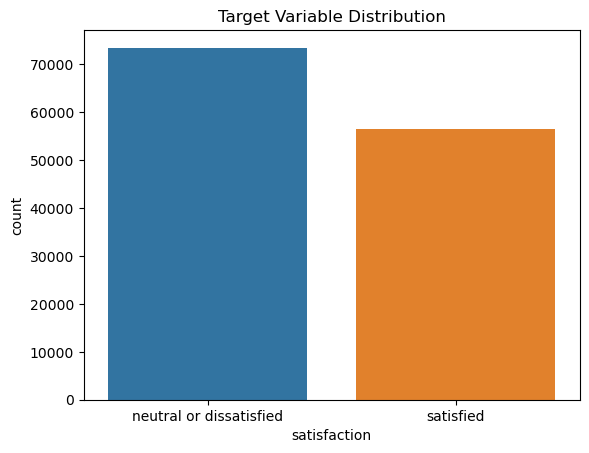

satisfaction
neutral or dissatisfied    56.553742
satisfied                  43.446258
Name: proportion, dtype: float64


In [64]:
"""
Analyze the distribution of passenger satisfaction.
"""

sns.countplot(x="satisfaction", data=df)
plt.title("Target Variable Distribution")
plt.show()

print(df["satisfaction"].value_counts(normalize=True) * 100)

The target variable is reasonably balanced, with approximately 57% of passengers classified as satisfied and 43% as dissatisfied.

This class distribution suggests that accuracy can be considered an appropriate evaluation metric, as severe class imbalance is not present.

### Passenger Satisfaction by Customer Type

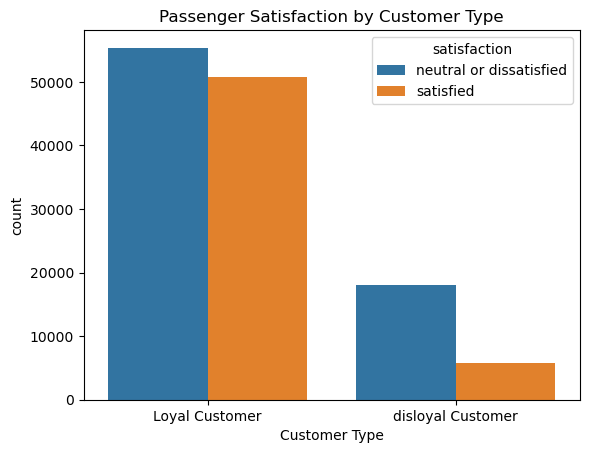

In [67]:
"""
Analyze passenger satisfaction across different customer types.
"""

sns.countplot(x="Customer Type", hue="satisfaction", data=df)
plt.title("Passenger Satisfaction by Customer Type")
plt.show()

Customer type appears to have a strong relationship with satisfaction.

Loyal customers tend to report higher satisfaction levels, while disloyal customers are more frequently associated with dissatisfaction.

### Passenger Satisfaction by Customer Gender 

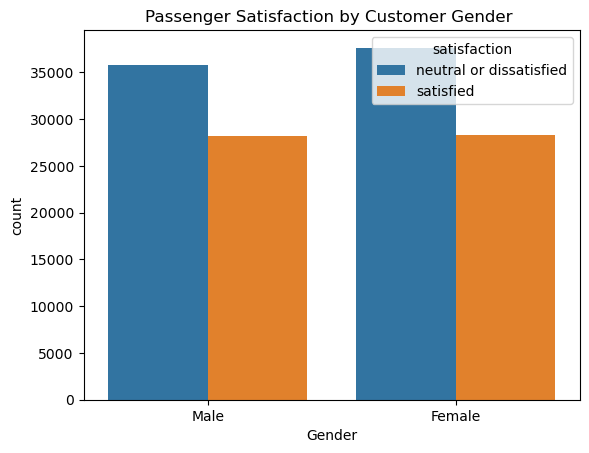

In [70]:
"""
Analyze passenger satisfaction across different genders.
"""

sns.countplot(x="Gender", hue="satisfaction", data=df)
plt.title("Passenger Satisfaction by Customer Gender ")
plt.show()

The distribution of satisfaction across genders is relatively similar.

This suggests that gender alone is unlikely to be a strong predictor of passenger satisfaction.

### Passenger Satisfaction by Customer Age

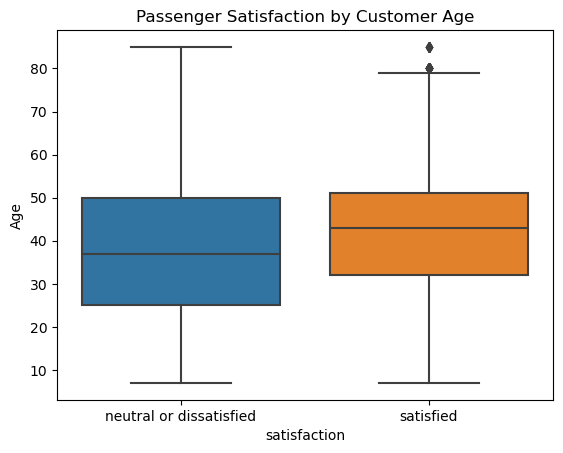

In [77]:
"""
Analyze the relationship between age and passenger satisfaction.
"""

sns.boxplot(x="satisfaction", y="Age", data=df)
plt.title("Passenger Satisfaction by Customer Age")
plt.show()

Passenger age shows variability across satisfaction groups.

Although some differences are observable, age alone does not appear to provide a clear separation between satisfied and dissatisfied passengers.

### Passenger Satisfaction by Flight Distance

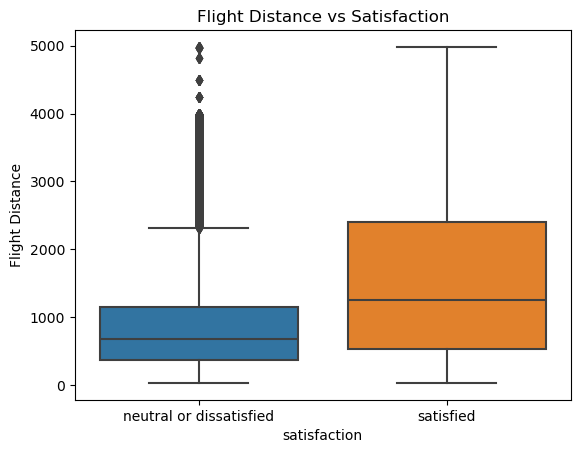

In [81]:
"""
Analyze the relationship between flight distance and passenger satisfaction.
"""

sns.boxplot(x="satisfaction", y="Flight Distance", data=df)
plt.title("Flight Distance vs Satisfaction")
plt.show()

Flight distance appears to be associated with passenger satisfaction.

Satisfied passengers tend to travel longer distances on average, suggesting that flight length may influence the overall travel experience.

### Passenger Class Distribution

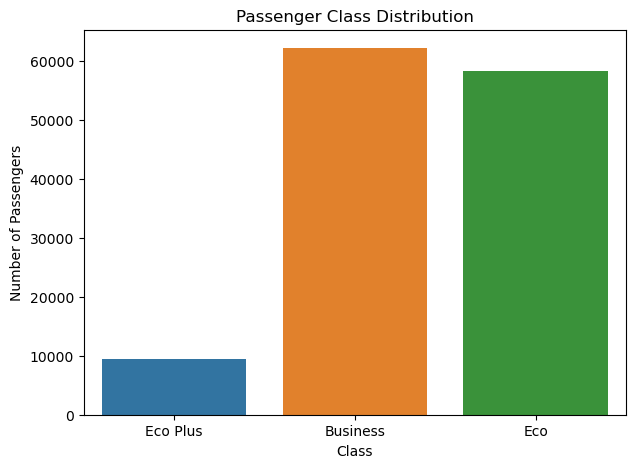

In [85]:
"""
Analyze the distribution of travel classes.
"""

plt.figure(figsize=(7,5))

sns.countplot(x="Class", data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Passengers")

plt.show()

Economy and Economy Plus are the most represented travel classes in the dataset, while Business Class accounts for a smaller proportion of passengers.

This distribution is important because travel class may be associated with passenger satisfaction and could therefore represent a relevant predictive feature.

### Passenger Satisfaction by Class

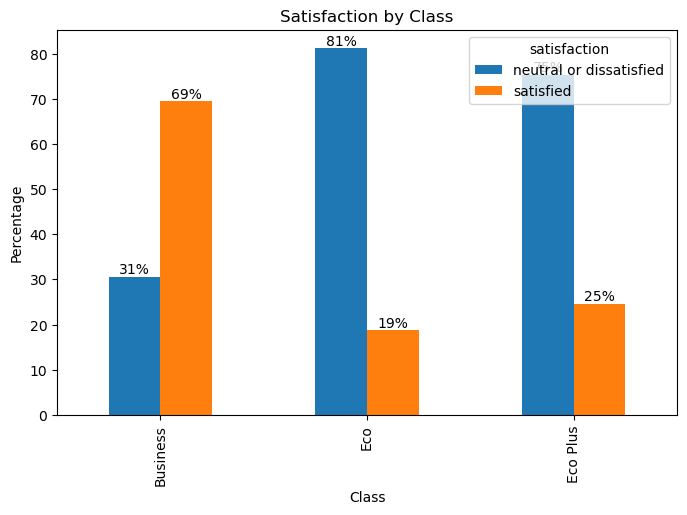

In [89]:
"""
Analyze the relationship between travel class and passenger satisfaction.
"""

df_plot = pd.crosstab(
    df["Class"],
    df["satisfaction"],
    normalize="index"
)

ax = df_plot.mul(100).plot(kind="bar", figsize=(8,5))

plt.ylabel("Percentage")
plt.title("Satisfaction by Class")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%")

plt.show()

Travel class shows a strong relationship with satisfaction.

Passengers traveling in Business Class are generally more satisfied than those traveling in Economy Class, highlighting the impact of service quality and travel conditions.

## Outliers Analysis

The Interquartile Range (IQR) is used to detect potential outliers in numerical features and represents the statistical dispersion of the central 50% of the data.

$$
IQR = Q_3 - Q_1
$$

In [94]:
"""
Outlier detection using the Interquartile Range (IQR) method.

The proportion of outliers is calculated for each numerical feature in the dataset.
"""

def iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers) / len(df) * 100


cols = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

for c in cols:
    print(c, iqr_outliers(df, c))

Age 0.0
Flight Distance 2.198182938096705
Departure Delay in Minutes 13.9344009855251
Arrival Delay in Minutes 13.555589775177088


Several numerical features contain extreme values according to the IQR method.

However, these observations were retained because they represent realistic travel scenarios rather than data entry errors. Removing them could lead to a loss of potentially valuable information.

### Transformation of Categorical into Numerical Features

In [98]:
"""
Transformation of categorical variables into numerical format.

Binary mapping is applied to dichotomous variables, while one-hot encoding is used for the 'Class' feature.
"""

df_encoded = df.copy()

df_encoded["Gender"] = df_encoded["Gender"].map({"Male": 0, "Female": 1})

df_encoded["Customer Type"] = df_encoded["Customer Type"].map({
    "disloyal Customer": 0,
    "Loyal Customer": 1
})

df_encoded["Type of Travel"] = df_encoded["Type of Travel"].map({
    "Personal Travel": 0,
    "Business travel": 1
})

df_encoded = pd.get_dummies(df_encoded, columns=["Class"])

df_encoded["satisfaction"] = df_encoded["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

### Correlation Analysis

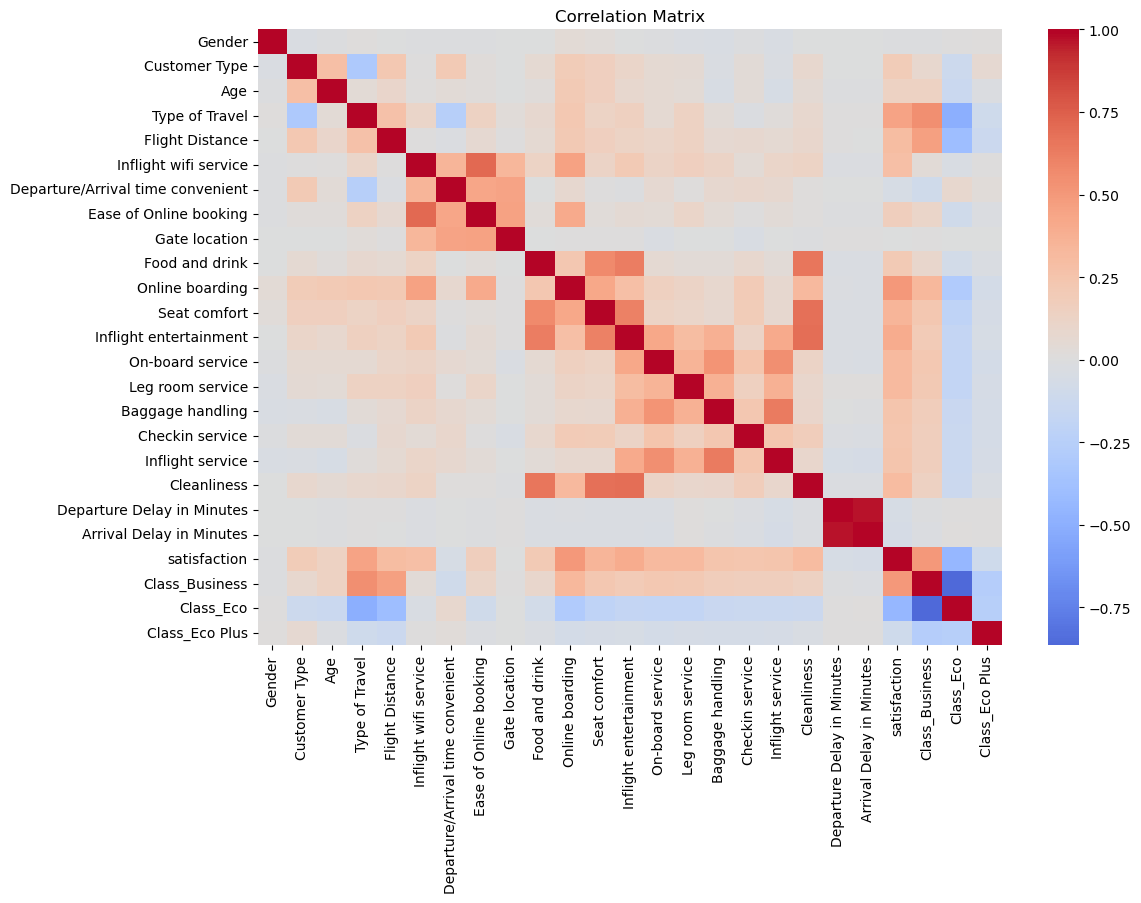

In [101]:
"""
Examination of correlations among numerical variables in the dataset to identify potential relationships and dependencies.
"""

corr = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

The correlation analysis reveals several relationships between the numerical variables.

In particular, Departure Delay and Arrival Delay exhibit a strong positive correlation, which is expected given the nature of flight operations.

Although this introduces a degree of redundancy, both variables were retained as they represent different stages of the travel experience: the departure phase and the actual arrival outcome. In this context, the potential issue of multicollinearity is less critical for tree-based models, which are generally robust to correlated features.

## Feature Selection

### Chi-Square Test

In [106]:
"""
Feature selection using the Chi-square test to identify the most relevant variables and assess their statistical dependence with the target variable.
"""

X = df_encoded.drop(columns=["satisfaction"])
y = df_encoded["satisfaction"].astype(int)

chi_scores, p_values = chi2(X, y)

chi_df = pd.DataFrame({
    "Feature": X.columns,
    "Chi2": chi_scores,
    "p-value": p_values
}).sort_values(by="Chi2", ascending=False)

print(chi_df)

                              Feature          Chi2        p-value
4                     Flight Distance  9.645859e+06   0.000000e+00
20           Arrival Delay in Minutes  4.295766e+04   0.000000e+00
19         Departure Delay in Minutes  3.293872e+04   0.000000e+00
10                    Online boarding  1.834034e+04   0.000000e+00
21                     Class_Business  1.709809e+04   0.000000e+00
22                          Class_Eco  1.445363e+04   0.000000e+00
2                                 Age  1.353949e+04   0.000000e+00
12             Inflight entertainment  1.091611e+04   0.000000e+00
3                      Type of Travel  8.132850e+03   0.000000e+00
11                       Seat comfort  7.993086e+03   0.000000e+00
5               Inflight wifi service  6.758345e+03   0.000000e+00
13                   On-board service  6.602710e+03   0.000000e+00
14                   Leg room service  6.554606e+03   0.000000e+00
18                        Cleanliness  6.429598e+03   0.000000

### Mutual Information

In [109]:
"""
Feature selection using Mutual Information to evaluate the dependency between features and the target variable and identify the most relevant predictors.
"""

mi = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI": mi
}).sort_values(by="MI", ascending=False)

print(mi_df)

                              Feature        MI
10                    Online boarding  0.213363
5               Inflight wifi service  0.165395
21                     Class_Business  0.142795
3                      Type of Travel  0.127180
22                          Class_Eco  0.115945
12             Inflight entertainment  0.098967
11                       Seat comfort  0.081103
14                   Leg room service  0.065282
4                     Flight Distance  0.062246
13                   On-board service  0.060481
18                        Cleanliness  0.055077
7              Ease of Online booking  0.052834
2                                 Age  0.045593
17                   Inflight service  0.045586
15                   Baggage handling  0.044231
16                    Checkin service  0.037661
1                       Customer Type  0.032618
9                      Food and drink  0.029637
8                       Gate location  0.014097
0                              Gender  0

The results of the Chi-square test indicate that several service-related variables (e.g., online boarding, inflight entertainment, and seat comfort) are highly relevant.

Mutual Information analysis also shows that features related to the in-flight customer experience are among the most informative, confirming their predictive importance.

Both methods consistently identify a set of variables strongly associated with customer satisfaction.

This supports the decision to include these features in the modeling phase and justifies the subsequent comparison between models trained on the full feature set and those using feature selection.

### T-Test Analysis

In [112]:
"""
Statistical analysis to evaluate significant differences between satisfied and dissatisfied groups across numerical variables.
"""

satisfied = df[df["satisfaction"] == "satisfied"]
unsatisfied = df[df["satisfaction"] == "neutral or dissatisfied"]

numeric_cols = [
    "Age",
    "Flight Distance",
    "Inflight wifi service",
    "Seat comfort",
    "Online boarding",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

ttest_results = []

for col in numeric_cols:
    stat, p = ttest_ind(satisfied[col], unsatisfied[col])
    ttest_results.append([col, p])

ttest_df = pd.DataFrame(ttest_results, columns=["Feature", "p-value"])
print(ttest_df.sort_values("p-value"))

                       Feature       p-value
0                          Age  0.000000e+00
1              Flight Distance  0.000000e+00
2        Inflight wifi service  0.000000e+00
3                 Seat comfort  0.000000e+00
4              Online boarding  0.000000e+00
5       Inflight entertainment  0.000000e+00
6             On-board service  0.000000e+00
7             Leg room service  0.000000e+00
8             Baggage handling  0.000000e+00
9              Checkin service  0.000000e+00
10            Inflight service  0.000000e+00
11                 Cleanliness  0.000000e+00
13    Arrival Delay in Minutes  2.181908e-97
12  Departure Delay in Minutes  8.634339e-75


The results show that many variables exhibit extremely low p-values (well below the typical significance threshold of 0.05).

This indicates that there are statistically significant differences between the two groups for these features.

In particular, service-related variables such as inflight WiFi service, seat comfort, online boarding, and inflight entertainment appear to be highly discriminative.

The T-test confirms the findings obtained from the Chi-square test and Mutual Information analysis, further supporting the selection of the most relevant features for the modeling phase.

The exploratory data analysis highlights that customer satisfaction is strongly influenced by service quality-related variables.

In particular, factors such as online boarding access, seat comfort, and inflight entertainment emerge as highly discriminative features.

These findings guide the subsequent modeling phase and feature selection process.

## Data Preprocessing

In [116]:
"""
Final dataset preparation for machine learning modeling.

The process includes data cleaning, categorical encoding, and feature engineering.
"""

def preprocess(df):
    """
    Preprocessing del dataset per modelli di machine learning.
    """
    
    df = df.drop(columns=["id", "Unnamed: 0"])

    df["Arrival Delay in Minutes"] = (
        df.groupby("Departure Delay in Minutes")["Arrival Delay in Minutes"]
        .transform(lambda x: x.fillna(x.median()))
    )

    df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
        df["Arrival Delay in Minutes"].median()
    )

    df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

    df["Customer Type"] = df["Customer Type"].map({
        "disloyal Customer": 0,
        "Loyal Customer": 1
    })

    df["Type of Travel"] = df["Type of Travel"].map({
        "Personal Travel": 0,
        "Business travel": 1
    })

    df = pd.get_dummies(df, columns=["Class"])

    return df

## Model Training and Evaluation

In [118]:
"""
Application of the preprocessing pipeline and separation of features and target variable.
"""
train_encoded = preprocess(train)
test_encoded = preprocess(test)

X_train = train_encoded.drop(columns=["satisfaction"])
y_train = train_encoded["satisfaction"]

X_test = test_encoded.drop(columns=["satisfaction"])
y_test = test_encoded["satisfaction"]

In [119]:
"""
Definition of a subset of selected features used for experimental comparison between models.
"""

selected_features = [
    "Online boarding",
    "Inflight entertainment",
    "Seat comfort",
    "Flight Distance"
]

X_train_sel = X_train[selected_features]

## Baseline Model

In [121]:
"""
Training and evaluation of a baseline classifier.

The DummyClassifier always predicts the majority class and provides
a reference benchmark for assessing the effectiveness of the
machine learning models.
"""

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)

print(f"Baseline Accuracy: {dummy_accuracy:.4f}")

Baseline Accuracy: 0.5610


The baseline classifier achieved an accuracy of 56%.

Since the DummyClassifier always predicts the majority class, this result represents the minimum performance threshold. Therefore, any machine learning model should significantly outperform this baseline to demonstrate its ability to learn meaningful patterns from the data.

## Model Comparison

In [124]:
"""
Comparison of machine learning models using cross-validation.

The evaluation metric used is the average accuracy over 5 folds.
The random_state parameter is set to ensure reproducibility of results.
"""

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000,random_state=SEED))
    ]),
    
    "AdaBoost": AdaBoostClassifier(random_state=SEED),
    
    "Random Forest": RandomForestClassifier(random_state=SEED)
}

results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    results.append(["All Features", name, scores.mean(), scores.std()])

for name, model in models.items():
    scores = cross_val_score(model, X_train_sel, y_train, cv=5, scoring="accuracy")
    results.append(["Selected Features", name, scores.mean(), scores.std()])

results_df = pd.DataFrame(results, columns=["Dataset", "Model", "Mean Accuracy", "Std"])
print(results_df.sort_values(by="Mean Accuracy", ascending=False))

             Dataset                Model  Mean Accuracy       Std
2       All Features        Random Forest       0.960974  0.000931
1       All Features             AdaBoost       0.927549  0.001968
0       All Features  Logistic Regression       0.874990  0.001999
4  Selected Features             AdaBoost       0.825117  0.001782
3  Selected Features  Logistic Regression       0.806629  0.002434
5  Selected Features        Random Forest       0.801355  0.001979


The best-performing models are those trained on the full feature set.

This behavior can be explained by the fact that, although some features may not appear highly significant individually, they can still contribute in a complementary way to the model’s predictive power.

Consequently, feature selection based solely on univariate statistical tests may lead to a loss of useful information, slightly affecting overall performance.

The cross-validation results show that ensemble models (Random Forest and AdaBoost) outperform Logistic Regression.

This is expected, as Logistic Regression is a linear model and assumes a linear relationship between features and the target variable. In this case, however, the relationship between input variables and customer satisfaction is more complex and non-linear.

On the other hand, Random Forest and AdaBoost are ensemble methods capable of capturing non-linear relationships and complex feature interactions.

## Hyperparameter Tuning

In [127]:
"""
Hyperparameter optimization of the Random Forest model using GridSearchCV to identify the best-performing parameter configuration based on cross-validation accuracy.
"""


rf = RandomForestClassifier(random_state=SEED)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()

grid_rf.fit(X_train, y_train)

end = time.time()

print("Random Forest GridSearch training time:", end - start, "seconds")

print(grid_rf.best_params_)
print(grid_rf.best_score_)

Random Forest GridSearch training time: 167.0401074886322 seconds
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
0.9616761776033755


In [128]:
"""
Hyperparameter optimization of Ada Boost using GridSearchCV to identify the best-performing parameter configuration based on cross-validation accuracy..
"""

ada = AdaBoostClassifier(random_state=SEED)

param_grid_ada = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1]
}

grid_ada = GridSearchCV(
    ada,
    param_grid_ada,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()

grid_ada.fit(X_train, y_train)

end = time.time()

print("AdaBoost GridSearch training time:", end - start, "seconds")

print(grid_ada.best_params_)
print(grid_ada.best_score_)

AdaBoost GridSearch training time: 102.44136309623718 seconds
{'learning_rate': 1, 'n_estimators': 200}
0.929338624129106


The results show that AdaBoost has a lower training time compared to Random Forest, indicating a faster hyperparameter optimization process.

Random Forest, while slightly more computationally expensive, may justify this cost if it provides better predictive performance.

Overall, the observed differences highlight the trade-off between computational efficiency and model complexity.

## Final Evaluation

=== Random Forest ===
                         precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.98      0.97     14573
              satisfied       0.97      0.94      0.96     11403

               accuracy                           0.96     25976
              macro avg       0.96      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976

=== AdaBoost ===
                         precision    recall  f1-score   support

neutral or dissatisfied       0.93      0.94      0.94     14573
              satisfied       0.92      0.91      0.92     11403

               accuracy                           0.93     25976
              macro avg       0.93      0.93      0.93     25976
           weighted avg       0.93      0.93      0.93     25976



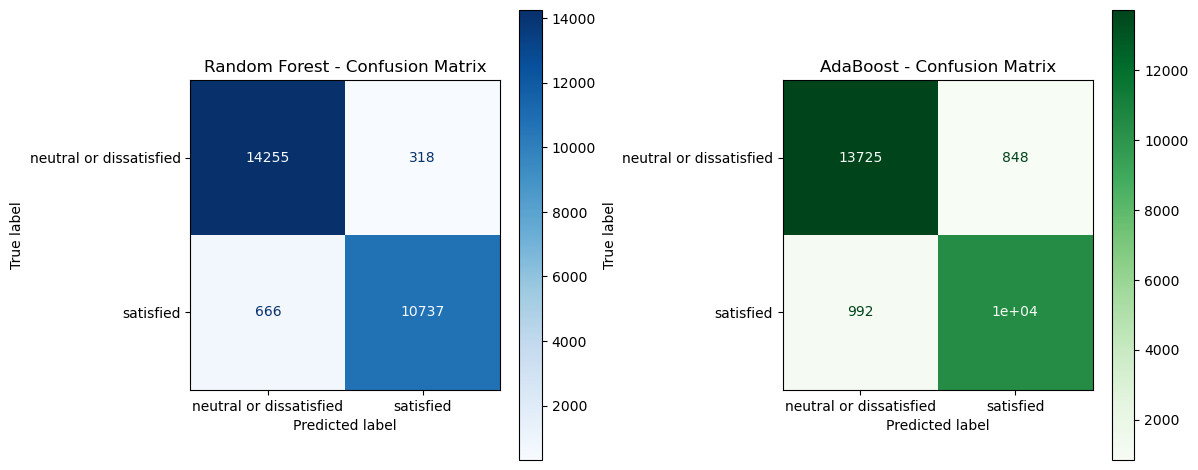

In [131]:
"""
Final evaluation of the optimized models on the test set using unseen data.
"""

best_rf = grid_rf.best_estimator_
best_ada = grid_ada.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_ada = best_ada.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

print("=== AdaBoost ===")
print(classification_report(y_test, y_pred_ada))

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=ax[0], cmap="Blues"
)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ada, ax=ax[1], cmap="Greens"
)

ax[0].set_title("Random Forest - Confusion Matrix")
ax[1].set_title("AdaBoost - Confusion Matrix")

plt.tight_layout()
plt.show()

The classification report provides a comprehensive overview of model performance.

The results show that both models achieve high performance, with Random Forest generally outperforming AdaBoost across all metrics.

In particular, the model demonstrates a good balance between precision and recall, indicating a stable ability to correctly classify both classes.

From the confusion matrices, it can be observed that:

- The Random Forest model exhibits a lower number of overall errors.
- Misclassifications are slightly imbalanced across the two classes, but remain limited.
- In particular, the model maintains a good balance between false positives and false negatives, resulting in greater stability.

AdaBoost shows a slightly higher number of errors compared to Random Forest.
A greater difficulty is observed in correctly classifying borderline instances, with a slight predominance of errors in one class.

These errors are not random but are mainly concentrated in ambiguous cases where service-related features are not sufficiently discriminative.

This suggests that the problem is well modeled, although some overlap between classes exists within the dataset.

## Evaluation Metrics

The following metrics are used to formally evaluate the performance of the classification models.

Accuracy is defined as:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Precision is defined as:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Recall is defined as:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

F1-score is defined as:

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

## Roc and Auc Analysis

Random Forest AUC: 0.9940
AdaBoost AUC: 0.9795


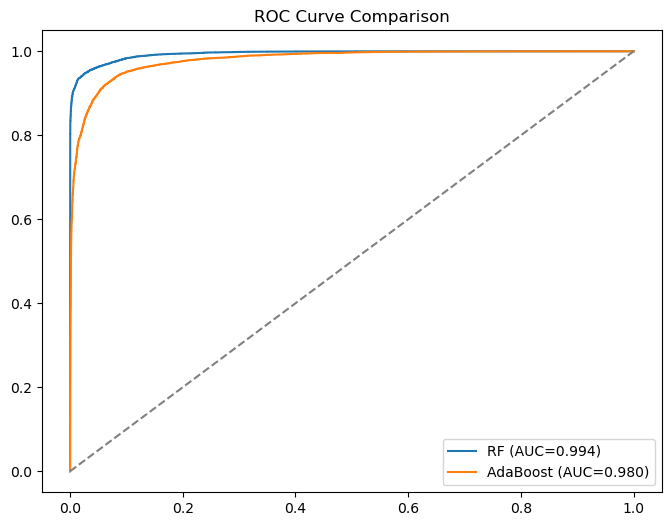

In [136]:
"""
Assessment of the models' discriminative performance using ROC curves and the Area Under the Curve (AUC) metric.
"""

y_test_bin = y_test.map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_prob_ada = best_ada.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test_bin, y_prob_rf)
auc_ada = roc_auc_score(y_test_bin, y_prob_ada)

print(f"Random Forest AUC: {auc_rf:.4f}")
print(f"AdaBoost AUC: {auc_ada:.4f}")

fpr_rf, tpr_rf, _ = roc_curve(y_test_bin, y_prob_rf)
fpr_ada, tpr_ada, _ = roc_curve(y_test_bin, y_prob_ada)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.3f})")
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC={auc_ada:.3f})")
plt.plot([0,1],[0,1],"--",color="gray")

plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

Both models exhibit high AUC values, confirming strong discriminative performance.

In particular, Random Forest and AdaBoost are both highly effective, with only marginal differences between them.

The ROC curve supports the conclusions obtained from accuracy and confusion matrix analysis, while providing a more robust evaluation as it is independent of the classification threshold.

## Overfitting Analysis

Assessment of model generalization through comparison of training and test accuracy.

Given the high predictive performance observed in previous evaluations, this step
aims to verify whether the model maintains consistent performance on unseen data
or exhibits signs of overfitting.

In [139]:
"""
Evaluation of potential overfitting by comparing training and test accuracy
of the trained Random Forest model.

The difference between train and test performance is used as an indicator
of the model's generalization capability.
"""


train_score = best_rf.score(X_train, y_train)
test_score = best_rf.score(X_test, y_test)

print("Train accuracy:", train_score)
print("Test accuracy:", test_score)
print("Difference:", train_score - test_score)

Train accuracy: 0.99591931013243
Test accuracy: 0.9621188789651987
Difference: 0.033800431167231304


In [140]:
"""
Evaluation of potential overfitting by comparing training and test accuracy
of the trained Adaboost model.

The difference between train and test performance is used as an indicator
of the model's generalization capability.
"""

train_score = best_ada.score(X_train, y_train)
test_score = best_ada.score(X_test, y_test)

print("Train accuracy:", train_score)
print("Test accuracy:", test_score)
print("Difference:", train_score - test_score)

Train accuracy: 0.9299834462580844
Test accuracy: 0.9291653834308593
Difference: 0.0008180628272250745


The overfitting analysis highlights a clear difference between the two models.

Random Forest shows a small gap of approximately 0.03 between training and test accuracy, indicating a slight degree of overfitting. However, the model still demonstrates good generalization performance, suggesting a reasonable bias-variance trade-off.

In contrast, AdaBoost exhibits an almost negligible gap of approximately 0.008, indicating excellent generalization and very low overfitting.

Overall, both models generalize well to unseen data, but AdaBoost appears to be more stable, while Random Forest achieves slightly higher flexibility at the cost of a marginally higher variance.

### Inference time

In [149]:
"""
Computation of inference time for the trained Random Forest model.

The execution time is measured on the test set during prediction to evaluate
the computational efficiency of the model in a realistic deployment scenario.
"""

start = time.time()

y_pred_rf = best_rf.predict(X_test)

end = time.time()

print("Random Forest inference time:", end - start, "seconds")

Random Forest inference time: 0.5736541748046875 seconds


In [150]:
"""
Computation of inference time for the trained AdaBoost model.

The execution time is measured on the test set during prediction to evaluate
the computational efficiency of the model in a realistic deployment scenario.
"""

start = time.time()

y_pred_ada = best_ada.predict(X_test)

end = time.time()

print("AdaBoost inference time:", end - start)

AdaBoost inference time: 0.47519969940185547


The inference time comparison between Random Forest and AdaBoost shows that both models achieve very fast prediction times on the test set.

Although minor differences may be observed, both models demonstrate low latency, confirming their suitability for practical deployment scenarios where computational efficiency is a relevant constraint alongside predictive performance.

### Seed Analysis

In [153]:
"""
Seed sensitivity analysis for Random Forest and AdaBoost models.

The goal is to evaluate stability across different random seeds,
keeping hyperparameters fixed from GridSearchCV.
"""

seeds = [1, 7, 21, 48, 99]


def seed_analysis(model_class, params, X, y, seeds, cv=5):
    """
    Perform seed sensitivity analysis for a given model.
    """
    
    scores = []
    
    for seed in seeds:
        
        params_with_seed = params.copy()
        params_with_seed["random_state"] = seed
        
        model = model_class(**params_with_seed)
        
        score = cross_val_score(model, X, y, cv=cv, scoring="accuracy").mean()
        scores.append(score)
    
    return scores


rf_params = grid_rf.best_params_.copy()
ada_params = grid_ada.best_params_.copy()

rf_scores = seed_analysis(RandomForestClassifier, rf_params, X_train, y_train, seeds)
ada_scores = seed_analysis(AdaBoostClassifier, ada_params, X_train, y_train, seeds)

print("RF scores per seed:", rf_scores)
print("RF std:", np.std(rf_scores))
print("RF range:", np.max(rf_scores) - np.min(rf_scores))

print("AdaBoost scores per seed:", ada_scores)
print("AdaBoost std:", np.std(ada_scores))
print("AdaBoost range:", np.max(ada_scores) - np.min(ada_scores))

RF scores per seed: [0.9617627984287676, 0.9617916709565575, 0.9617724193626749, 0.9616761776033755, 0.9616665585220527]
RF std: 5.200594295500826e-05
RF range: 0.0001251124345047483
AdaBoost scores per seed: [0.929338624129106, 0.929338624129106, 0.929338624129106, 0.929338624129106, 0.929338624129106]
AdaBoost std: 0.0
AdaBoost range: 0.0


The results indicate that both models exhibit very low variability across different random seeds.

The extremely small standard deviation and narrow range of accuracy values suggest that model performance is highly stable and not driven by stochastic effects in the training process.

This implies that the learned patterns in the dataset are consistent and robust, and that the models are primarily capturing underlying structure rather than random fluctuations in the data.

### Feature importance

                              Feature  Importance
10                    Online boarding    0.164680
5               Inflight wifi service    0.150531
3                      Type of Travel    0.086372
21                     Class_Business    0.085755
12             Inflight entertainment    0.058636
22                          Class_Eco    0.053979
11                       Seat comfort    0.041379
7              Ease of Online booking    0.038139
1                       Customer Type    0.035921
14                   Leg room service    0.033985
4                     Flight Distance    0.031176
13                   On-board service    0.028898
2                                 Age    0.028831
18                        Cleanliness    0.025314
15                   Baggage handling    0.024521
17                   Inflight service    0.022361
16                    Checkin service    0.022027
6   Departure/Arrival time convenient    0.014483
8                       Gate location    0.014022


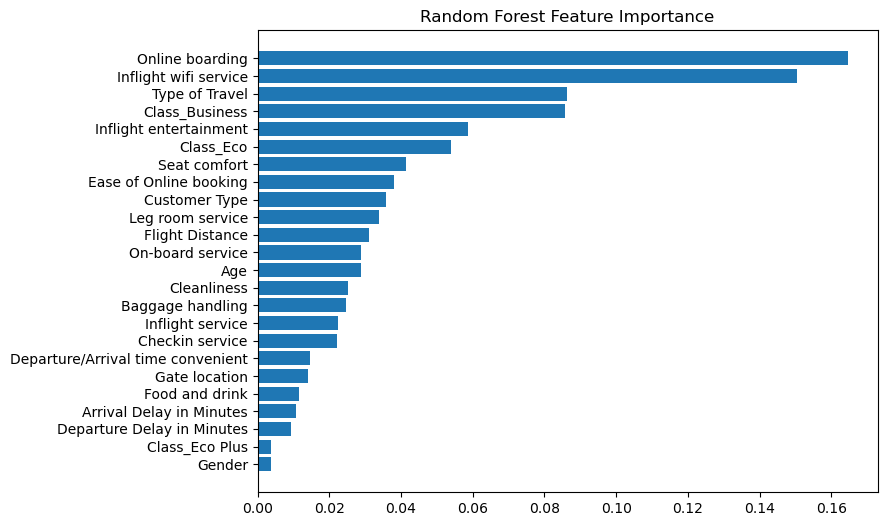

In [156]:
"""
Feature importance analysis for the trained Random Forest model.

The analysis quantifies the contribution of each feature to the model's predictive
performance. Features are ranked in descending order of importance to highlight
the most influential variables in determining passenger satisfaction.

A horizontal bar plot is used to improve interpretability and provide a clear
visual summary of the results.
"""

importances = best_rf.feature_importances_

feat_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_importance)

plt.figure(figsize=(8,6))
plt.barh(feat_importance["Feature"], feat_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()

A feature importance analysis was performed on the trained Random Forest model to gain interpretability of the prediction process.

The feature importance analysis highlights that customer experience-related variables are the most influential in predicting satisfaction.

In particular, Online boarding and Inflight WiFi service are the most significant predictors, followed by Type of Travel and passenger Class, indicating that both service quality and travel context strongly impact customer satisfaction.

Features related to in-flight comfort and entertainment (such as inflight entertainment, seat comfort, and leg room service) also show substantial importance, confirming the central role of onboard experience.

On the other hand, variables such as Gender, Class_Eco Plus, and delay-related features exhibit relatively low importance, suggesting a limited contribution to the predictive performance of the model.

Overall, the results are consistent with previous statistical analyses (Chi-square, Mutual Information, and T-test), reinforcing the robustness of the identified key drivers of customer satisfaction.

## Conclusions

This project focused on the development and evaluation of machine learning models for predicting passenger satisfaction based on flight experience and service-related features. The workflow followed a complete end-to-end machine learning pipeline, including data preprocessing, exploratory data analysis, feature selection, model training, hyperparameter optimization, and final evaluation.

During the exploratory phase, the analysis highlighted that service-related variables (such as onboard services, seat comfort, inflight entertainment, and online boarding) play a central role in determining passenger satisfaction. Statistical tests further confirmed that several features exhibit significant differences between satisfied and unsatisfied passengers, reinforcing their predictive relevance.

Feature selection techniques, including Chi-square tests and Mutual Information, helped identify the most informative variables and provided additional insight into the factors influencing customer satisfaction. 
In particular, service quality-related features consistently emerged as the most relevant predictors of satisfaction.

Three different models were evaluated: Logistic Regression, Random Forest, and AdaBoost.

The comparison with a baseline DummyClassifier further confirmed the effectiveness of the proposed machine learning models. Since the baseline achieved an accuracy of approximately 56% by always predicting the majority class, it provided a minimum performance threshold. All trained models substantially outperformed this benchmark, demonstrating their ability to learn meaningful patterns from the data.

Among the evaluated approaches, ensemble-based methods (Random Forest and AdaBoost) significantly outperformed Logistic Regression, confirming that non-linear relationships and feature interactions play an important role in this problem. Random Forest achieved the best overall performance in terms of accuracy and classification metrics, followed closely by AdaBoost.

A rigorous evaluation phase was conducted using confusion matrices, classification reports, and ROC-AUC curves. The results showed strong predictive performance across both classes, with slightly better recall for the majority class and high overall discrimination ability.

An overfitting analysis was also performed by comparing training and test accuracy. The results revealed only a small performance gap for Random Forest and an almost negligible gap for AdaBoost, indicating that both models generalize well to unseen data. These findings further support the robustness and reliability of the proposed approaches.

A seed sensitivity analysis demonstrated that both Random Forest and AdaBoost are highly stable with respect to variations in random initialization, with negligible fluctuations in accuracy across different seeds. This confirms that the models are not significantly influenced by stochastic effects and are reliable in terms of reproducibility.

Furthermore, a feature importance analysis applied to the Random Forest model provided interpretability, showing which variables contribute most to the prediction process. This added a valuable explanatory layer, transforming the model from a purely predictive tool into a more interpretable decision-support system.

In addition to predictive performance, computational efficiency was also considered. Training time during GridSearchCV and inference time on the test set were measured to evaluate the trade-off between performance and computational cost. The results showed that while ensemble models are slightly more computationally expensive during training, they remain efficient in inference, making them suitable for practical deployment scenarios.

In conclusion, the Random Forest model emerged as the best-performing approach, offering a strong balance between accuracy, robustness, and interpretability. However, the analysis also highlights the importance of considering computational cost and model stability alongside predictive performance when selecting a model for real-world applications. Overall, the project demonstrates how a structured machine learning pipeline can effectively address a real classification problem while maintaining a balance between performance, robustness, and practical usability.